# BÁO CÁO TRỰC QUAN HÓA: TIỀN XỬ LÝ & TRÍCH XUẤT ĐẶC TRƯNG HÌNH ẢNH

Notebook này chứa toàn bộ mã nguồn trực quan hóa nhằm minh họa chi tiết 3 nhiệm vụ đã thực hiện:
1. **Nhiệm vụ 1:** Tiền xử lý ảnh (Resize & Normalize).
2. **Nhiệm vụ 2:** Trích xuất đặc trưng thủ công (HSV Histogram, LBP, Hu Moments, GLCM Texture, HOG Structure).
3. **Nhiệm vụ 3:** Chuẩn hóa dữ liệu (StandardScaler) và Giảm chiều trực quan hóa (PCA & t-SNE).

In [11]:
# Chạy cell này để cài đặt đồng bộ toàn bộ thư viện cần thiết từ requirements.txt
# %pip là lệnh magic của Jupyter giúp cài đặt chính xác vào môi trường (kernel) đang chạy Notebook này
%pip install -r ../requirements.txt

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'd:\\program files\\python311\\lib\\site-packages\\matplotlib\\backends\\_backend_agg.cp311-win_amd64.pyd'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu121
  Using cached attrs-26.1.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached certifi-2026.4.22-py3-none-any.whl.metadata (2.5 kB)
  Using cached charset_normalizer-3.4.7-cp311-cp311-win_amd64.whl.metadata (41 kB)
  Using cached filelock-3.29.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached fsspec-2026.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached idna-3.15-py3-none-any.whl.metadata (7.7 kB)
  Using cached https://download.pytorch.org/whl/jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached matplotlib-3.10.9-cp311-cp311-win_amd64.whl.metadata (52 kB)
  Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl.metadata (61 kB)
  Using cached outcome-1.3.0.post0-py2.py3-none-any.whl.metadata (2.6 kB)
  Using cached packaging-26.2-py3-none-any.whl.metadata (3.5 kB)
  Using cached PySocks-1.7.1-py3-none-any.whl.metadata (13 kB)
  Using cached requests-2.34.1-py3-none-any.whl.metadata (4.8 kB)


In [1]:
import os
import sys
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import feature
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Import các hàm từ feature_extraction
try:
    from skimage.feature import hog, graycomatrix, graycoprops
except ImportError:
    from skimage.feature import hog, greycomatrix as graycomatrix, greycoprops as graycoprops

# Cấu hình hệ thống dẫn đường import
sys.path.append(os.path.abspath('../'))
from src.models.utils.preprocessing import resize_with_padding
from src.models.feature_extraction import (
    extract_all_features, 
    extract_hsv_histogram, 
    extract_lbp, 
    extract_hu_moments,
    extract_glcm_features,
    extract_hog_features
)

print('✅ Khởi tạo và import thư viện thành công!')

ModuleNotFoundError: No module named 'matplotlib.backends.registry'

## 🖼️ Nhiệm Vụ 1: Tiền Xử Lý Ảnh (Resize & Normalize)
Chúng ta sẽ so sánh ảnh gốc (kích thước gốc) và ảnh sau khi đã resize về **128x128 kèm theo padding** để chống méo ảnh, đồng thời chuẩn hóa giá trị pixel về đoạn $[0, 1]$.

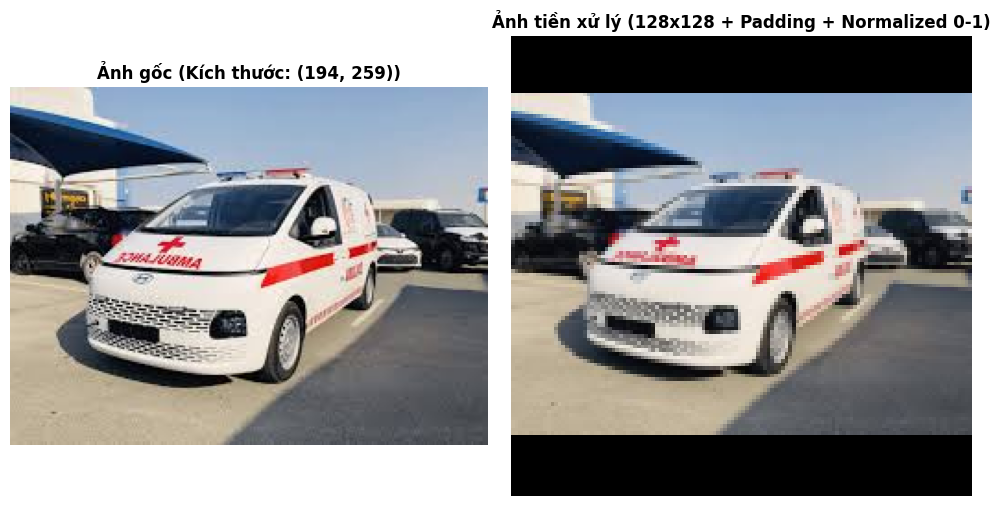

In [13]:
# Đường dẫn tới một ảnh mẫu thực tế
sample_image_path = '../data/raw/ambulance/ambulance_000000000001.jpg'

if not os.path.exists(sample_image_path):
    print(f"⚠️ Không tìm thấy file mẫu tại '{sample_image_path}'. Vui lòng chạy split_dataset.py trước.")
else:
    # 1. Đọc ảnh gốc bằng OpenCV và chuyển đổi sang RGB để hiển thị đúng màu
    img_original = cv2.imread(sample_image_path)
    img_original_rgb = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)
    
    # 2. Áp dụng tiền xử lý (ảnh kết quả có kích thước 224x224 và kiểu dữ liệu float32 trong [0,1])
    img_processed = resize_with_padding(sample_image_path, target_size=(224, 224))
    img_processed_rgb = cv2.cvtColor((img_processed * 255).astype(np.uint8), cv2.COLOR_BGR2RGB)
    print(f'Kích thước ảnh gốc: {img_original.shape}')
    print(f'Kích thước ảnh sau tiền xử lý: {img_processed.shape}')
    
    # 3. Vẽ so sánh
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    axes[0].imshow(img_original_rgb)
    axes[0].set_title(f'Ảnh gốc (Kích thước: {img_original.shape[:2]})', fontsize=12, fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(img_processed_rgb)
    axes[1].set_title(f'Ảnh tiền xử lý (Kích thước: {img_processed.shape[:2]} + Padding + Normalized 0-1)', fontsize=12, fontweight='bold')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

## 🎨 Nhiệm Vụ 2: Trích Xuất Đặc Trưng Thủ Công

### 1. Đặc trưng màu sắc: HSV Color Histogram (64 chiều)

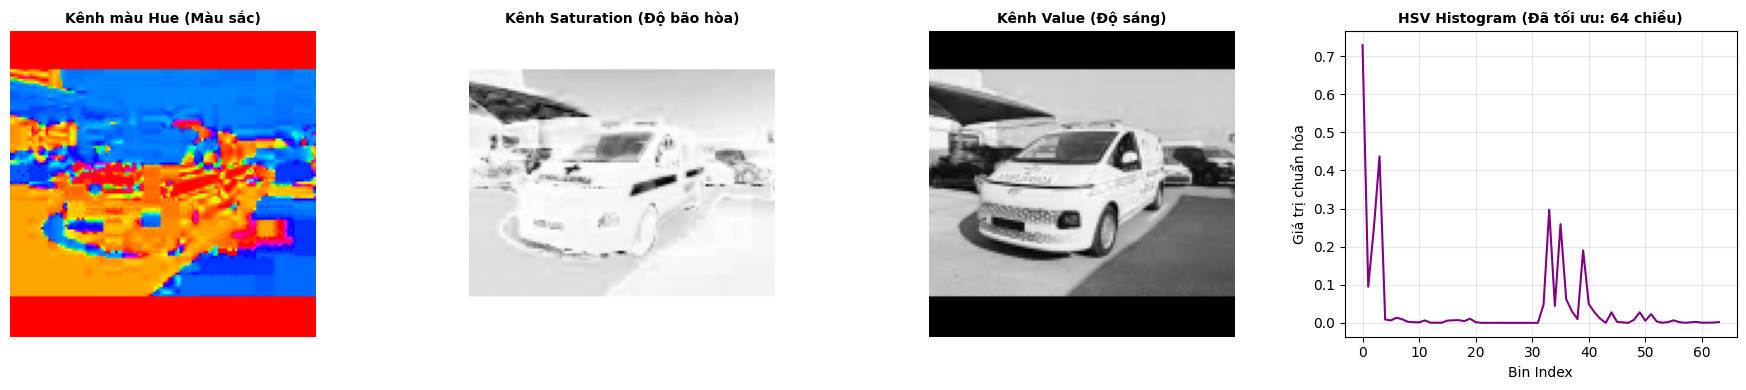

In [14]:
if os.path.exists(sample_image_path):
    # Trích xuất biểu đồ màu HSV (64 chiều)
    hsv_hist = extract_hsv_histogram(img_processed)
    
    # Biến đổi ảnh sang không gian màu HSV
    image_uint8 = (img_processed * 255).astype(np.uint8)
    hsv_image = cv2.cvtColor(image_uint8, cv2.COLOR_BGR2HSV)
    
    # Vẽ các kênh HSV và biểu đồ
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    
    axes[0].imshow(hsv_image[:, :, 0], cmap='hsv')
    axes[0].set_title('Kênh màu Hue (Màu sắc)', fontsize=10, fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(hsv_image[:, :, 1], cmap='Greys')
    axes[1].set_title('Kênh Saturation (Độ bão hòa)', fontsize=10, fontweight='bold')
    axes[1].axis('off')
    
    axes[2].imshow(hsv_image[:, :, 2], cmap='gray')
    axes[2].set_title('Kênh Value (Độ sáng)', fontsize=10, fontweight='bold')
    axes[2].axis('off')
    
    axes[3].plot(hsv_hist, color='purple', lw=1.5)
    axes[3].set_title('HSV Histogram (Đã tối ưu: 64 chiều)', fontsize=10, fontweight='bold')
    axes[3].set_xlabel('Bin Index')
    axes[3].set_ylabel('Giá trị chuẩn hóa')
    axes[3].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

### 2. Đặc trưng kết cấu: LBP (Local Binary Pattern) (26 chiều)
LBP chụp lại các cấu trúc bề mặt cục bộ (như vân lốp, vành bánh xe, lưới tản nhiệt). Kết cấu được phân tích qua ảnh xám.

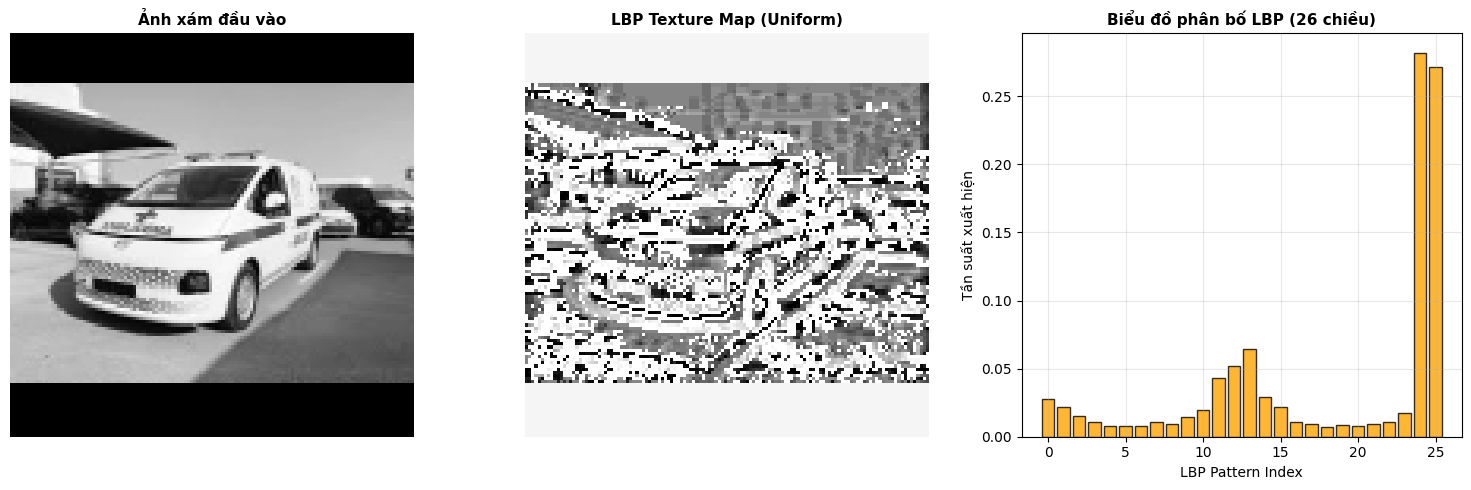

In [15]:
if os.path.exists(sample_image_path):
    # Tính toán ảnh xám
    gray = cv2.cvtColor(image_uint8, cv2.COLOR_BGR2GRAY)
    
    # Tính LBP map trực quan
    num_points = 24
    radius = 3
    lbp_map = feature.local_binary_pattern(gray, num_points, radius, method='uniform')
    
    # Lấy vector histogram LBP
    lbp_hist = extract_lbp(img_processed, num_points=num_points, radius=radius)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(gray, cmap='gray')
    axes[0].set_title('Ảnh xám đầu vào', fontsize=11, fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(lbp_map, cmap='gray')
    axes[1].set_title('LBP Texture Map (Uniform)', fontsize=11, fontweight='bold')
    axes[1].axis('off')
    
    axes[2].bar(range(len(lbp_hist)), lbp_hist, color='orange', edgecolor='black', alpha=0.8)
    axes[2].set_title('Biểu đồ phân bố LBP (26 chiều)', fontsize=11, fontweight='bold')
    axes[2].set_xlabel('LBP Pattern Index')
    axes[2].set_ylabel('Tần suất xuất hiện')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

### 3. Đặc trưng kết cấu: Haralick GLCM (Gray-Level Co-occurrence Matrix)
GLCM ghi nhận tần suất xuất hiện đồng thời của các mức xám đứng gần nhau ở các hướng xoay và khoảng cách pixel định sẵn, sinh ra các chỉ số: Contrast (độ tương phản), Energy (năng lượng), Correlation (độ tương quan)...

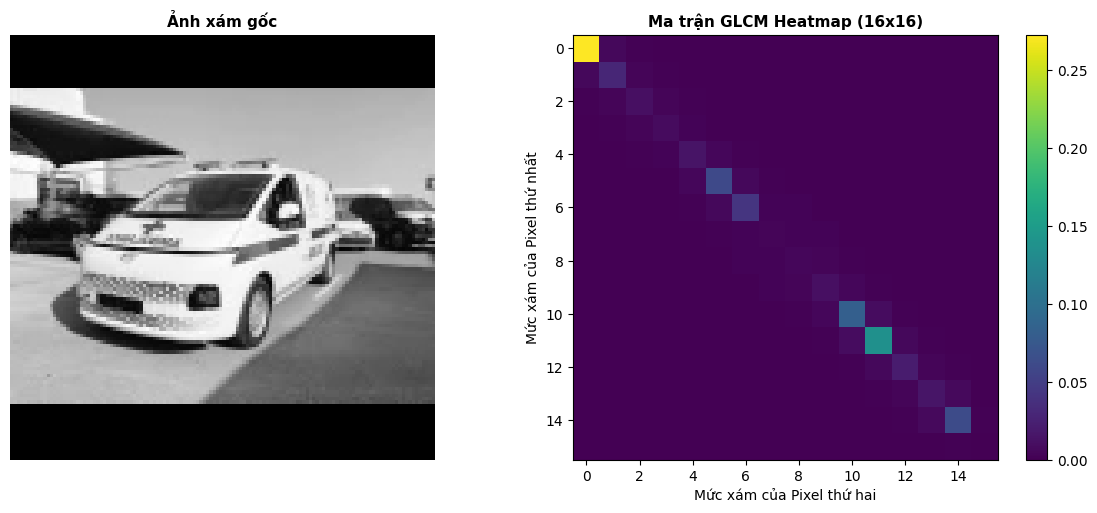

✅ Trích xuất GLCM (Haralick): 40 chiều đặc trưng (Contrast, Homogeneity, Correlation, Energy...).


In [16]:
if os.path.exists(sample_image_path):
    # Thu hẹp về 16 mức xám để tính toán GLCM
    gray_16 = (gray / 16).astype(np.uint8)
    
    # Tính GLCM cho khoảng cách d=1, hướng xoay 0 độ
    glcm_single = graycomatrix(gray_16, distances=[1], angles=[0], levels=16, symmetric=True, normed=True)
    glcm_matrix = glcm_single[:, :, 0, 0]
    
    # Trích xuất 40 đặc trưng
    glcm_feats = extract_glcm_features(img_processed)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    axes[0].imshow(gray, cmap='gray')
    axes[0].set_title('Ảnh xám gốc', fontsize=11, fontweight='bold')
    axes[0].axis('off')
    
    # Trực quan hóa ma trận GLCM dưới dạng Heatmap màu sắc
    im = axes[1].imshow(glcm_matrix, cmap='viridis')
    axes[1].set_title('Ma trận GLCM Heatmap (16x16)', fontsize=11, fontweight='bold')
    axes[1].set_xlabel('Mức xám của Pixel thứ hai')
    axes[1].set_ylabel('Mức xám của Pixel thứ nhất')
    fig.colorbar(im, ax=axes[1])
    
    plt.tight_layout()
    plt.show()
    
    print(f'✅ Trích xuất GLCM (Haralick): {len(glcm_feats)} chiều đặc trưng (Contrast, Homogeneity, Correlation, Energy...).')

### 4. Đặc trưng hình dạng: Hu Moments (7 chiều)
Hu Moments mô tả các đặc tính hình học dạng khối (như dáng xe đứng, ngang hay vuông) thông qua thuật toán phân tích mô-men không gian trên ảnh nhị phân tách nền.

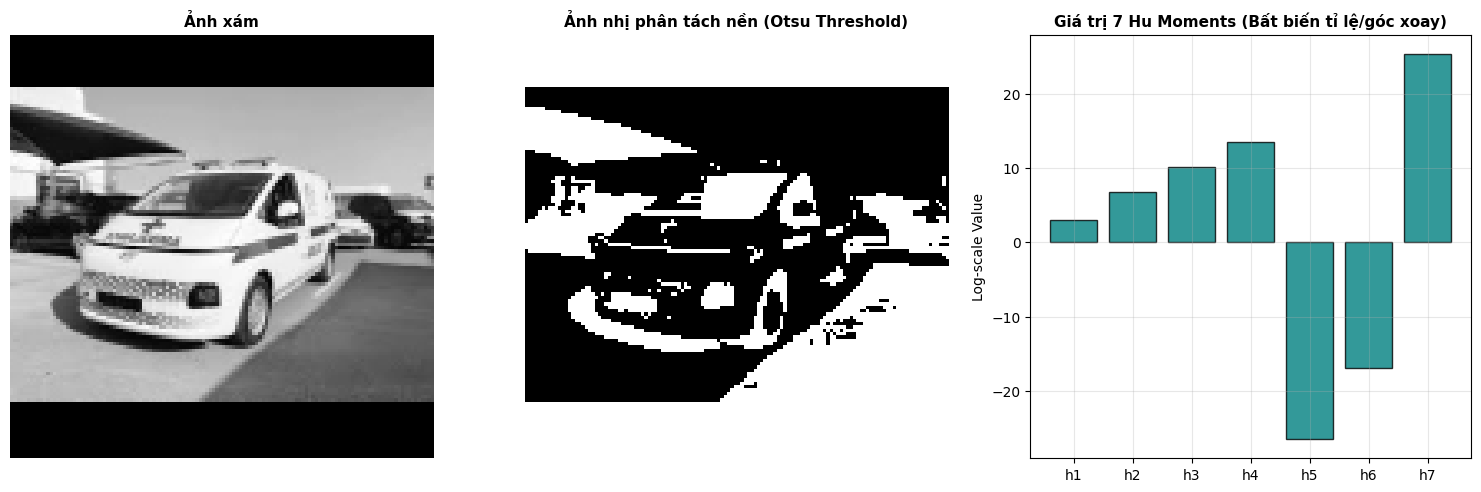

In [17]:
if os.path.exists(sample_image_path):
    # Tạo ảnh nhị phân phân tách bằng thuật toán Otsu
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # Tính Hu Moments
    hu_moments = extract_hu_moments(img_processed)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(gray, cmap='gray')
    axes[0].set_title('Ảnh xám', fontsize=11, fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(thresh, cmap='binary')
    axes[1].set_title('Ảnh nhị phân tách nền (Otsu Threshold)', fontsize=11, fontweight='bold')
    axes[1].axis('off')
    
    # Vẽ biểu đồ giá trị logarithmic của 7 mô-men Hu
    axes[2].bar([f'h{i+1}' for i in range(7)], hu_moments, color='teal', edgecolor='black', alpha=0.8)
    axes[2].set_title('Giá trị 7 Hu Moments (Bất biến tỉ lệ/góc xoay)', fontsize=11, fontweight='bold')
    axes[2].set_ylabel('Log-scale Value')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

### 5. Đặc trưng cấu trúc: HOG (Histogram of Oriented Gradients) (1764 chiều)
HOG tính toán sự phân bố của hướng các vector gradient (độ dốc sáng) ở các vùng ô lưới (cells). Đây là đặc trưng mạnh mẽ nhất mô tả chính xác kết cấu khung sườn, viền bánh xe, viền kính xe để mô hình phân loại phương tiện.

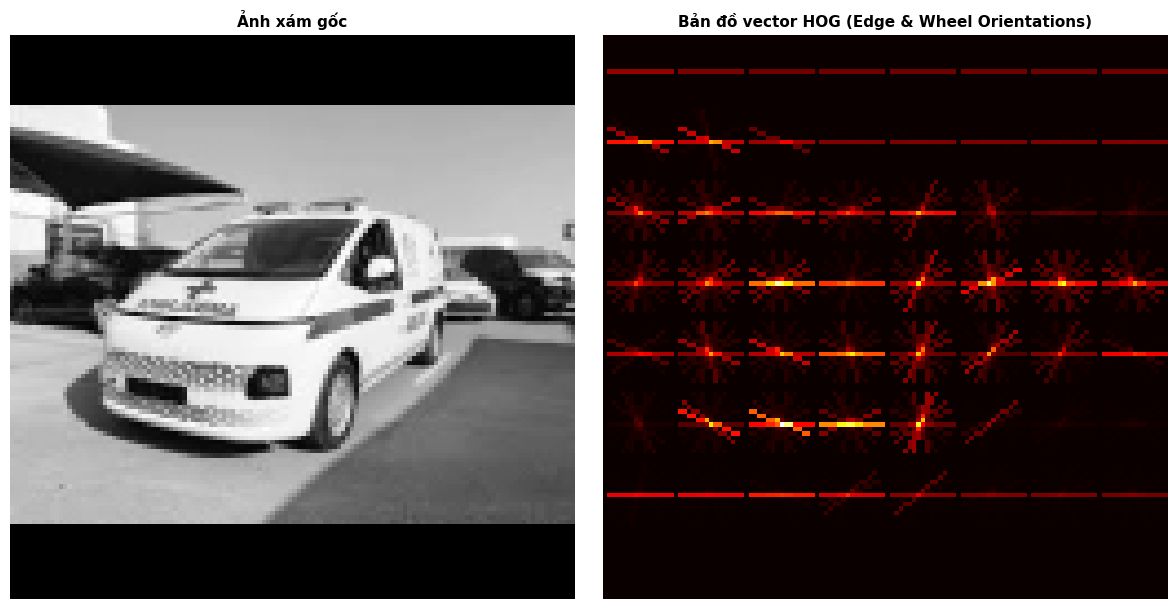

✅ Kích thước đặc trưng HOG trích xuất: 1764 chiều. HOG nắm giữ các thông tin cấu trúc vật thể.


In [18]:
if os.path.exists(sample_image_path):
    # Tính HOG map và ảnh trực quan hóa
    hog_feats, hog_image = hog(gray, orientations=9, pixels_per_cell=(16, 16), 
                               cells_per_block=(2, 2), visualize=True, channel_axis=None)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    axes[0].imshow(gray, cmap='gray')
    axes[0].set_title('Ảnh xám gốc', fontsize=11, fontweight='bold')
    axes[0].axis('off')
    
    # Phóng đại cường độ để xem viền HOG rõ hơn
    axes[1].imshow(hog_image, cmap='hot')
    axes[1].set_title('Bản đồ vector HOG (Edge & Wheel Orientations)', fontsize=11, fontweight='bold')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f'✅ Kích thước đặc trưng HOG trích xuất: {len(hog_feats)} chiều. HOG nắm giữ các thông tin cấu trúc vật thể.')

## 📊 Nhiệm Vụ 3: Chuẩn Hóa, Giảm Chiều & Trực Quan Hóa Phân Cụm (PCA & t-SNE)
Chúng ta nạp toàn bộ tập đặc trưng đã trích xuất mới (đầy đủ 6221 chiều), áp dụng StandardScaler và giảm về 2D bằng PCA và t-SNE.

**Lưu ý:** Bạn cần chạy lại script `python scripts/prepare_features.py` từ Terminal để cập nhật file đặc trưng `.npy` trước khi chạy cell dưới đây.

In [19]:
features_dir = '../data/features'
raw_dir = '../data/raw'

X_path = os.path.join(features_dir, 'X_train.npy')
y_path = os.path.join(features_dir, 'y_train.npy')

if not os.path.exists(X_path) or not os.path.exists(y_path):
    print("❌ Lỗi: Bạn cần chạy file 'scripts/prepare_features.py' trước để tạo đặc trưng (.npy)")
else:
    # 1. Tải đặc trưng và nhãn
    X = np.load(X_path)
    y = np.load(y_path)
    print(f'Đang xử lý tập đặc trưng có kích thước: {X.shape}')
    
    # Lấy tên nhãn class phương tiện
    if os.path.exists(raw_dir):
        class_names = sorted([d for d in os.listdir(raw_dir) if os.path.isdir(os.path.join(raw_dir, d))])
    else:
        class_names = [f'Class {i}' for i in np.unique(y)]
        
    # 2. StandardScaler
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # 3. PCA (2 thành phần)
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)
    
    # 4. t-SNE kết hợp PCA làm sạch nhiễu đầu vào (PCA -> 50 dims -> t-SNE)
    # Chúng ta sử dụng PCA để giảm nhiễu trước, sau đó mới dùng t-SNE để gom cụm tốt nhất
    pca_noise_filter = PCA(n_components=min(50, X.shape[1]), random_state=42)
    X_pca_50 = pca_noise_filter.fit_transform(X_scaled)
    
    np.random.seed(42)
    subset_idx = np.random.choice(X.shape[0], min(2000, X.shape[0]), replace=False)
    X_subset = X_pca_50[subset_idx]
    y_subset = y[subset_idx]
    
    print('⏳ Đang thực hiện giảm chiều t-SNE...')
    tsne = TSNE(n_components=2, perplexity=40, n_iter=1000, random_state=42, n_jobs=-1)
    X_tsne = tsne.fit_transform(X_subset)
    print('✅ Đã chuẩn bị xong dữ liệu giảm chiều!')

Đang xử lý tập đặc trưng có kích thước: (7000, 6221)
⏳ Đang thực hiện giảm chiều t-SNE...
✅ Đã chuẩn bị xong dữ liệu giảm chiều!


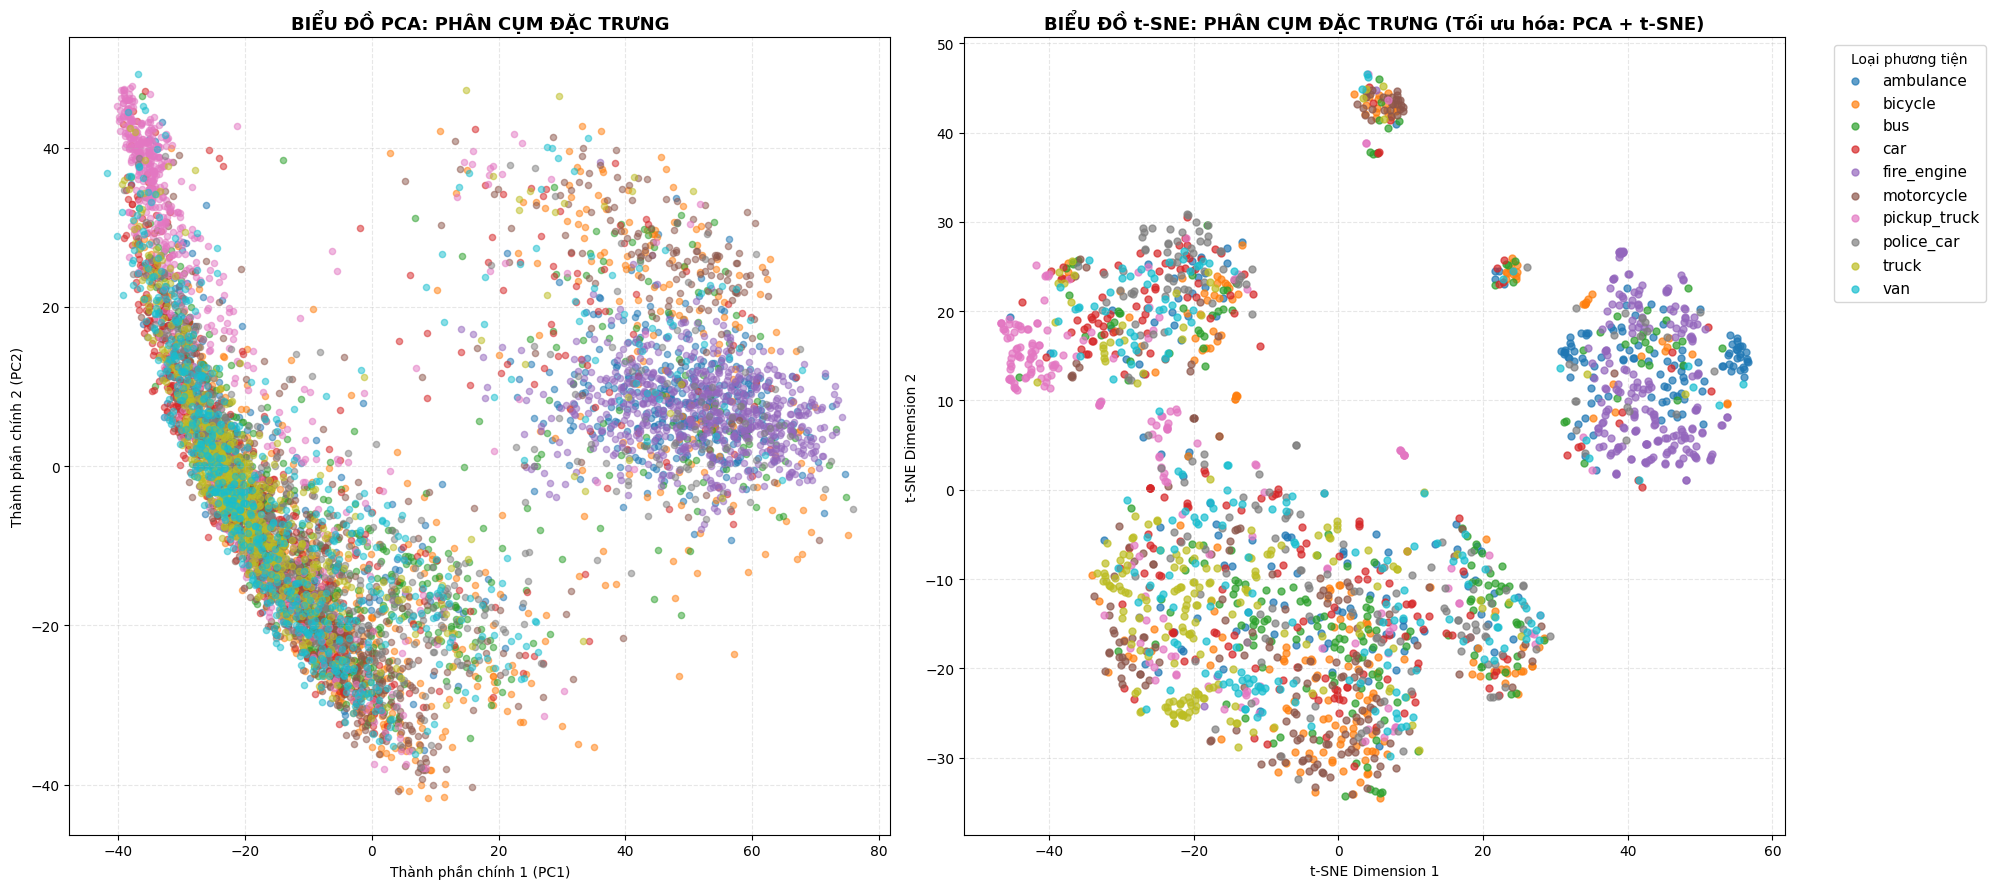

In [20]:
# Bảng màu đẹp
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
          '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

fig, axes = plt.subplots(1, 2, figsize=(20, 9))

# A. Vẽ đồ thị PCA
for i, class_name in enumerate(class_names):
    mask = (y == i)
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], label=class_name, 
                    color=colors[i % len(colors)], alpha=0.5, s=20)
axes[0].set_title('BIỂU ĐỒ PCA: PHÂN CỤM ĐẶC TRƯNG', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Thành phần chính 1 (PC1)')
axes[0].set_ylabel('Thành phần chính 2 (PC2)')
axes[0].grid(True, linestyle='--', alpha=0.3)

# B. Vẽ đồ thị t-SNE
for i, class_name in enumerate(class_names):
    mask = (y_subset == i)
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1], label=class_name, 
                    color=colors[i % len(colors)], alpha=0.7, s=25)
axes[1].set_title('BIỂU ĐỒ t-SNE: PHÂN CỤM ĐẶC TRƯNG (Tối ưu hóa: PCA + t-SNE)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('t-SNE Dimension 1')
axes[1].set_ylabel('t-SNE Dimension 2')
axes[1].grid(True, linestyle='--', alpha=0.3)

# Cấu hình chung chú thích
plt.legend(title='Loại phương tiện', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)
plt.tight_layout()
plt.show()